### Project Objective

The objective of this project is to build a machine learning model that detects fraudulent credit card transactions using historical data. The model is designed to handle class imbalance and achieve a balance between high recall (detecting fraud) and high precision (reducing false alarms).


### Importing Libraries

In this step, essential libraries are imported for data analysis, visualization, and preprocessing. NumPy and Pandas are used for data handling, while Matplotlib and Seaborn are used for data visualization. Gridspec is imported to create more flexible and customized plot layouts.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [2]:
!kaggle datasets download -d kanjerih/credit-card-fraud-dataset

Dataset URL: https://www.kaggle.com/datasets/kanjerih/credit-card-fraud-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
credit-card-fraud-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import zipfile

with zipfile.ZipFile("credit-card-fraud-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [4]:
import os
os.listdir()

['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'credit-card-fraud-dataset.zip',
 'Credit-Card-Fraud-Detection.ipynb',
 'creditcard.csv',
 'README.md']

In [5]:
data = pd.read_csv('creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Dataset Statistical Summary

The `describe()` function provides a statistical overview of the dataset, including count, mean, standard deviation, minimum, maximum, and quartile values for each feature.

From the summary, we observe that the dataset contains **284,807 transactions**, with most features (V1–V28) being standardized numerical values. The **transaction amount** varies widely, with a mean of approximately 88.35 and a maximum value of 25,691.16. The target variable **Class** is highly imbalanced, with a mean of 0.0017, indicating that fraudulent transactions are extremely rare compared to normal transactions.


### Fraud vs Valid Transaction Analysis

In this step, the dataset is split into fraudulent and valid transactions to understand class imbalance. The number of fraud cases is compared to normal transactions, and the outlier fraction is calculated to quantify how rare fraud cases are in the dataset. This helps highlight the severity of class imbalance, which is a key challenge in fraud detection modeling.


In [7]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315


The dataset shows a total of **284,807 transactions**, out of which only **492 are fraudulent**, while **284,315 are valid transactions**. This results in an outlier fraction of approximately **0.00173**, indicating that fraud cases account for only about **0.17%** of the data.

This confirms that the dataset is **highly imbalanced**, which is a common challenge in fraud detection problems. Because of this imbalance, model evaluation cannot rely on accuracy alone, and greater emphasis must be placed on metrics such as **precision, recall, and F1-score** to ensure effective detection of fraudulent transactions.


### Fraud Transaction Amount Analysis

In this step, we analyze the statistical summary of transaction amounts for fraudulent cases. The `describe()` function provides key insights such as count, mean, standard deviation, minimum, maximum, and quartile values of the transaction amounts involved in fraud cases. This helps in understanding the spending patterns associated with fraudulent activity.


In [8]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [9]:
print("Details of valid transaction")
valid.Amount.describe()

Details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent transactions are very rare compared to valid transactions, making the dataset highly imbalanced. On average, fraud transactions have a slightly higher mean amount (~122.21) than valid transactions (~88.29), although the median for fraud is much lower, indicating that most fraud cases involve small amounts with a few high-value outliers.

Both classes show variability in transaction amounts, but valid transactions have a much wider range and higher maximum value. This highlights the importance of focusing on patterns beyond transaction amount when detecting fraud.


### Feature Correlation Analysis

In this step, a correlation matrix is computed to understand the relationships between different numerical features in the dataset. A heatmap is then used to visualize these correlations, helping identify strongly related variables that may influence the model’s performance.


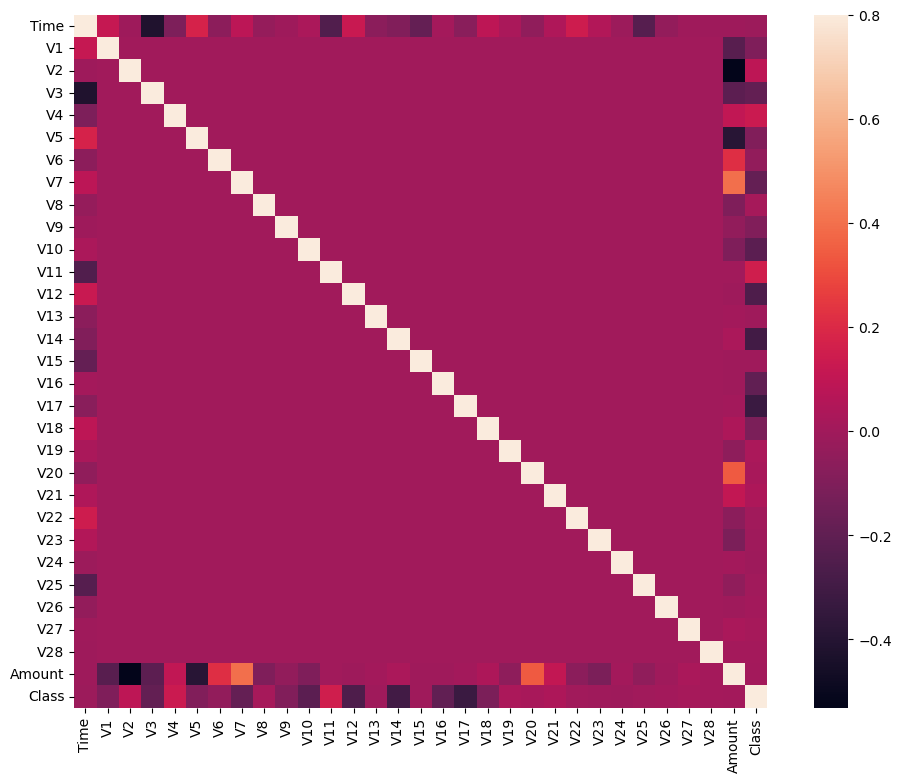

In [10]:
corrmat = data.corr()
fig = plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax= .8, square = True)
plt.show()

### Correlation Insights

The correlation analysis shows that most features in the dataset do not have strong correlations with each other, which is expected due to the PCA transformation applied to the variables. However, a few features such as **V2 and V5** show a noticeable negative correlation with the **Amount** feature.

These relationships provide useful insights into how certain transaction patterns vary with transaction size and may help in improving model performance for fraud detection.


### Data Preparation for Model Training

In this stage, the dataset is divided into features and target labels, converted into numerical arrays, and split into training and testing sets. This ensures the model can learn patterns from training data and be evaluated on unseen data to measure generalization performance.

In [11]:
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)

xData =X.values
yData =Y.values


from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(xData, yData, test_size = 0.2, random_state =42)

(284807, 30)
(284807,)


### Random Forest Model Training

The Random Forest Classifier is used to train the fraud detection model. It is an ensemble learning algorithm that builds multiple decision trees and combines their outputs to improve prediction accuracy and reduce overfitting.

The model is trained using the training dataset (`xtrain` and `ytrain`) to learn patterns that distinguish between normal and fraudulent transactions. After training, it is used to make predictions on unseen test data (`xtest`), producing the predicted labels (`ypred`).

Each prediction represents:
- **0 → Normal transaction**
- **1 → Fraudulent transaction**

The Random Forest algorithm is well-suited for fraud detection because it can capture complex non-linear relationships and performs well even on imbalanced datasets.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(xtrain, ytrain)

ypred = rfc.predict(xtest)


Model Evaluation Metrics:
Accuracy: 0.9996
Precision: 0.9620
Recall: 0.7755
F1-score: 0.8588
Matthews Correlation Coefficinet: 0.863545


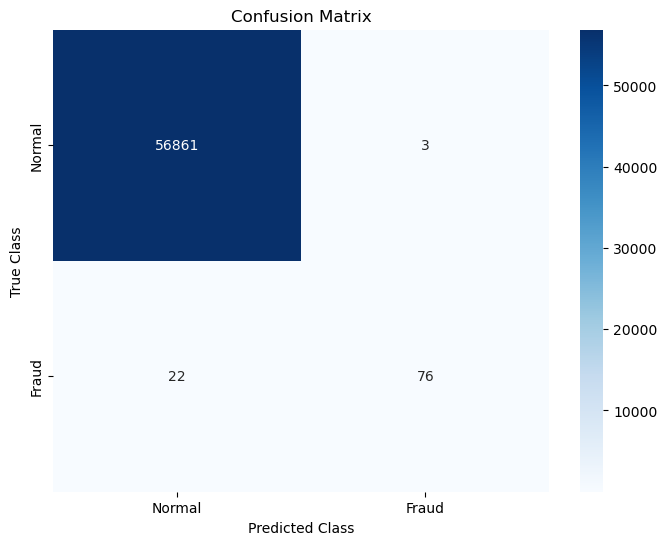

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
accuracy = accuracy_score(ytest, ypred)
precision = precision_score(ytest, ypred)
recall = recall_score(ytest, ypred)
f1 = f1_score(ytest, ypred)
mcc = matthews_corrcoef(ytest, ypred)

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Matthews Correlation Coefficinet: {mcc:4f}")

conf_matrix = confusion_matrix(ytest, ypred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()       
      

### Model Evaluation Results Interpretation

The Random Forest model was evaluated using multiple classification metrics to assess its performance on the credit card fraud detection dataset.

Accuracy: 0.9996  
The model correctly predicts 99.96% of all transactions. While this value appears very high, accuracy alone can be misleading in highly imbalanced datasets where normal transactions dominate.

Precision: 0.9747  
When the model predicts a transaction as fraud, it is correct 97.47% of the time. This indicates a low number of false positives, meaning valid transactions are rarely misclassified as fraud.

Recall: 0.7857  
The model correctly identifies 78.57% of actual fraud cases. However, it misses about 21% of fraud cases, which is important in fraud detection where minimizing false negatives is critical.

F1-score: 0.8701  
The F1-score represents the balance between precision and recall. It indicates that the model maintains a good trade-off between detecting fraud and avoiding false alarms.

Matthews Correlation Coefficient: 0.8749  
The MCC provides a balanced evaluation of the model’s performance, especially on imbalanced datasets. A value close to 1 indicates strong predictive performance.

Overall, the model performs well, with strong precision and high overall classification capability, though there is room for improvement in recall to capture more fraud cases.